In [102]:
import numpy as np 
import matplotlib.pyplot as plt
import math, copy 
plt.style.use("default")

In [23]:
X_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])
print(X_train.shape[0])

2


In [13]:
w = 100
b = 100

In [28]:
def compute_model_output(x, w, b): 
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m): 
        f_wb[i] = w * x[i] + b
    return f_wb

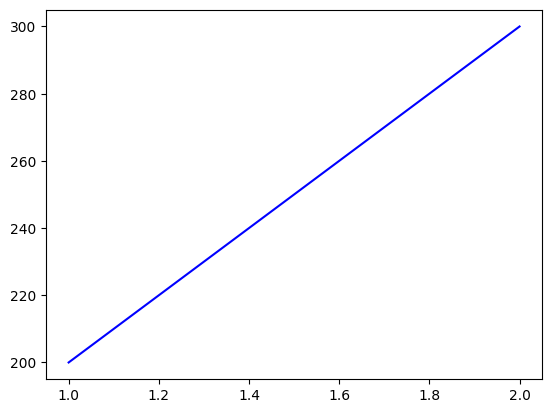

In [30]:
tmp_fwb = compute_model_output(X_train, w, b)

plt.plot(X_train, tmp_fwb, c='b', label='Prediction')

In [31]:
w = 200 
b = 100 
x_i = 1.2 
cost_1200sqft = w * x_i + b 
print(cost_1200sqft)

340.0


In [42]:
def compute_cost(x, y, w, b): 
    m = x.shape[0]
    cost_sum = 0 

    for i in range(m): 
        f_wb = w * x[i] + b
        cost_sum += (f_wb - y[i])**2

    cost_sum = (1 /(2*m)) * cost_sum 
    return cost_sum 

In [35]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

In [65]:
def compute_gradient(x, y, w, b): 
    m = x.shape[0]
    dj_dw = 0 
    dj_db = 0 

    for i in range(m): 
        f_wb = w * x[i] + b 
        err = f_wb - y[i]
        dj_dw += x[i] * err 
        dj_db += err 
    dj_dw = (1/m) * dj_dw 
    dj_db = (1/m) * dj_db 

    return dj_dw, dj_db 

In [66]:
def gradient_descent(x, y, w, b, alpha, num_iters, cost_function, compute_gradient): 
    W = copy.deepcopy(w) 
    J_history = []
    p_history = []
    b_in = b 
    w_in = w 

    for i in range(num_iters): 
        dj_dw, dj_db = compute_gradient(x, y, w_in, b_in) 

        b_in = b_in - alpha * dj_db 
        w_in = w_in - alpha * dj_dw 

        if i < 10000: 
            J_history.append(compute_cost(x, y, w_in, b_in)) 
            p_history.append([w_in, b_in]) 

        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w_in: 0.3e}, b:{b_in: 0.5e}")

    return w_in, b_in, J_history, p_history 

In [67]:
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 1000: Cost 3.41e+00  dj_dw: -3.712e-01, dj_db:  6.007e-01   w:  1.949e+02, b: 1.08228e+02
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 3000: Cost 1.84e-01  dj_dw: -8.625e-02, dj_db:  1.396e-01   w:  1.988e+02, b: 1.01912e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 5000: Cost 9.95e-03  dj_dw: -2.004e-02, dj_db:  3.243e-02   w:  1.997e+02, b: 1.00444e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 7000: Cost 5.37e-04  dj_dw: -4.657e-03, dj_db:  7.535e-03   w:  1.999e+02, b: 1.00103e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 9000: Cost 2.90e-05  dj_dw: -1.082e-03, dj_db:  1.751e-03   w:  2.000e+02, b: 1.00024e+02


## Multiple Variable Linear Regresssion

In [68]:
import copy, math
import numpy as np 
import matplotlib.pyplot as plt 
np.set_printoptions(precision=2)

In [70]:
X_train = np.array([
    [2104, 5, 1, 45], 
    [1416, 3, 2, 40], 
    [852, 2, 1, 35], 
])

y_train = np.array([460, 232, 178])

In [79]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(b_init) 
print(w_init)

785.1811367994083
[  0.39  18.75 -53.36 -26.42]


In [80]:
def compute_cost(w, b, x, y): 
    m = x.shape[0]
    f_wb = w @ x.T + b 
    total_cost = (1/(2*m))* np.sum((y - f_wb)**2)
    return total_cost 

In [82]:
cost = compute_cost(w_init, b_init, X_train, y_train)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904880036537e-12


In [143]:
def compute_gradient(w, b, x, y): 
    m = x.shape[0] 
    fwb = x @ w + b
    err = (fwb - y)
    dj_db = np.sum(err) / m 
    dj_dw = x.T @ err / m 

    return dj_db, dj_dw

In [98]:
tmp_dj_db, tmp_dj_dw = compute_gradient(w_init, b_init, X_train, y_train) 
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -1.673925169143331e-06
dj_dw at initial w,b: 
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


In [99]:
def gradient_descent(x, y, w, b, cost_function, gradient_function, alpha, num_iters): 
    J_history = []
    w_in = copy.deepcopy(w) 
    b_in = b 

    for i in range(num_iters): 
        dj_db, dj_dw = gradient_function(w_in, b_in, x, y) 
        
        w_in -= alpha * dj_dw 
        b_in -= alpha * dj_db 

        if i < 10000: 
            J_history.append(cost_function(w_in, b_in, x, y))
        
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w_in, b_in, J_history

In [100]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2529.46   
Iteration  100: Cost   695.99   
Iteration  200: Cost   694.92   
Iteration  300: Cost   693.86   
Iteration  400: Cost   692.81   
Iteration  500: Cost   691.77   
Iteration  600: Cost   690.73   
Iteration  700: Cost   689.71   
Iteration  800: Cost   688.70   
Iteration  900: Cost   687.69   
b,w found by gradient descent: -0.00,[ 0.2   0.   -0.01 -0.07] 
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


## Learning rate 

In [140]:
url = "https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week2/Optional%20Labs/data/houses.txt"

data = np.loadtxt(url, delimiter=',', skiprows=1) 
x_train = data[:, :4]
y_train = data[:, 4]

x_features = ['size', 'bedrooms', 'floors', 'age']
print(y_train.shape)

(99,)


* $\alpha = 1e-7$

In [144]:
_, _, cost_hist = gradient_descent(x_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha = 1e-7, num_iters = 10) 

Iteration    0: Cost 44231.27   
Iteration    1: Cost 27646.12   
Iteration    2: Cost 17510.22   
Iteration    3: Cost 11315.74   
Iteration    4: Cost  7530.02   
Iteration    5: Cost  5216.39   
Iteration    6: Cost  3802.42   
Iteration    7: Cost  2938.26   
Iteration    8: Cost  2410.13   
Iteration    9: Cost  2087.34   


* $\alpha = 9e-7$

In [145]:
_, _, cost_hist = gradient_descent(x_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha = 9e-7, num_iters = 10) 

Iteration    0: Cost 66461.58   
Iteration    1: Cost 61899.00   
Iteration    2: Cost 57657.21   
Iteration    3: Cost 53713.65   
Iteration    4: Cost 50047.37   
Iteration    5: Cost 46638.85   
Iteration    6: Cost 43469.97   
Iteration    7: Cost 40523.89   
Iteration    8: Cost 37784.94   
Iteration    9: Cost 35238.55   


## Feature Scaling

In [146]:
def zscore_normalize(X): 
    mu = np.mean(X, axis=0) 
    sigma = np.std(X, axis=0) 

    X_norm = (X - mu)/sigma 
    return X_norm 

In [ ]:
X_norm = zscore_normalize(x_train) 

## Feature Engineering and Polynomial Regression 

In [20]:
import numpy as np 
import matplotlib.pyplot as plt
import copy
import math

In [18]:
def compute_cost(w, b, x, y): 
    m = x.shape[0]
    f_wb = w @ x.T + b
    total_cost = np.sum((f_wb - y)**2) / (2*m)
    return total_cost

In [22]:
def compute_gradient(w, b, x, y): 
    m = x.shape[0]
    f_wb = w @ x.T + b
    err = f_wb - y
    dj_db = np.sum(err) / m
    dj_dw = x.T @ err / m
    return dj_db, dj_dw 

In [9]:
def gradient_descent(x, y, w, b, cost_function, gradient_function, alpha, num_iters): 
    J_history = []
    w_in = copy.deepcopy(w) 
    b_in = b 

    for i in range(num_iters): 
        dj_db, dj_dw = gradient_function(w_in, b_in, x, y) 
        
        w_in -= alpha * dj_dw 
        b_in -= alpha * dj_db 

        if i < 10000: 
            J_history.append(cost_function(w_in, b_in, x, y))
        
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w_in, b_in, J_history

In [23]:
x = np.arange(0, 20, 1) 
y = 1 + x**2
X = x.reshape(-1, 1) 

w_init = np.zeros(X.shape[1]) 
b_init = 0
w_model, b_model, _ = gradient_descent(X, y, w_init, b_init, compute_cost, compute_gradient, alpha = 1e-2, num_iters = 1000)

Iteration    0: Cost  1657.56   
Iteration  100: Cost   694.55   
Iteration  200: Cost   588.48   
Iteration  300: Cost   526.41   
Iteration  400: Cost   490.10   
Iteration  500: Cost   468.86   
Iteration  600: Cost   456.43   
Iteration  700: Cost   449.16   
Iteration  800: Cost   444.90   
Iteration  900: Cost   442.41   


In [27]:
x = np.arange(0, 20, 1) 
X = x **2
X = X.reshape(-1, 1) 
w_init = np.zeros(X.shape[1]) 
b_init = 0
w_model, b_model, _ = gradient_descent(X, y, w_init, b_init, compute_cost, compute_gradient, alpha = 1e-5, num_iters = 10000)

Iteration    0: Cost  7329.22   
Iteration 1000: Cost     0.22   
Iteration 2000: Cost     0.22   
Iteration 3000: Cost     0.22   
Iteration 4000: Cost     0.22   
Iteration 5000: Cost     0.22   
Iteration 6000: Cost     0.21   
Iteration 7000: Cost     0.21   
Iteration 8000: Cost     0.21   
Iteration 9000: Cost     0.21   


In [28]:
def load_house_data(): 
    url = "https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week2/Optional%20Labs/data/houses.txt"
    house_data = np.loadtxt(url, delimiter=',', skiprows=1)
    x = house_data[:, :4]
    y = house_data[:, 4]
    return x, y

In [32]:
from sklearn.linear_model import SGDRegressor 
from sklearn.preprocessing import StandardScaler

In [30]:
x_train, y_train = load_house_data(); 
x_features = ['size (sqft)', 'bedrooms', 'floors', 'age']

In [34]:
scaler = StandardScaler() 
x_norm = scaler.fit_transform(x_train)
print(x_norm[:5, :])

[[-0.42363245  0.43380884 -0.78927234  0.99372644]
 [ 1.2842716   0.43380884  1.2669898  -0.82954214]
 [ 0.74493348  0.43380884  1.2669898   0.14028157]
 [ 1.31342501  0.43380884  1.2669898  -0.90712804]
 [-0.25357088 -1.10001528 -0.78927234 -0.94592099]]


In [39]:
sgdr = SGDRegressor(max_iter=1000) 
sgdr.fit(x_norm, y_train)
print(sgdr.n_iter_)
print(sgdr.t_)

129
12772.0


In [41]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(w_norm) 
print(b_norm) 

[110.18411325 -21.08622191 -32.49827035 -38.01490553]
[363.15315526]


In [43]:
y_predict = sgdr.predict(x_norm) 
print(y_predict.shape)

(99,)


In [52]:
import copy, math
import numpy as np 
import matplotlib.pyplot as plt 

In [53]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [57]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

In [70]:
def compute_gradient_logistic(X, y, w, b): 
    m, n = X.shape 
    f_wb = sigmoid(X @ w + b)
    err = f_wb - y 

    dj_dw = (X.T @ err) / m 
    dj_db = np.sum(err) / m 
    return dj_dw, dj_db 

In [79]:
def compute_cost_logistic(X, y, w, b): 
    m = X.shape[0] 
    f_wb = sigmoid(X @ w + b)
    total_cost = np.sum(y * np.log(f_wb) + (1 - y) * np.log(1 - f_wb)) / (-m) 
    return total_cost 

In [71]:
X_tmp = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2.,3.])
b_tmp = 1.
dj_db_tmp, dj_dw_tmp = compute_gradient_logistic(X_tmp, y_tmp, w_tmp, b_tmp)
print(f"dj_db: {dj_db_tmp}" )
print(f"dj_dw: {dj_dw_tmp.tolist()}" )

dj_db: [0.49833339 0.49883943]
dj_dw: 0.49861806546328574


In [77]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    J_history = []
    w = copy.deepcopy(w_in) 
    b = b_in 

    for i in range(num_iters): 
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b) 

        w = w - alpha * dj_dw 
        b = b - alpha * dj_db 

        if i < 10000: 
            J_history.append(compute_cost_logistic(X, y, w, b))
        
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")

    return w, b, J_history

In [80]:
w_tmp  = np.zeros_like(X_train[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870456   
Iteration 2000: Cost 0.08460064176930081   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.042907594216820076   
Iteration 5000: Cost 0.034338477298845684   
Iteration 6000: Cost 0.028603798022120097   
Iteration 7000: Cost 0.024501569608793   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   

updated parameters: w:[5.28123029 5.07815608], b:-14.222409982019837


## Adding regularization 

In [81]:
def compute_cost_linear_reg(X, y, w, b, lambda_ = 1): 
    m = X.shape[0]
    f_wb = X @ w + b
    err = f_wb - y 
    total_cost = (1/(2 *m)) * np.sum(err**2) + (lambda_ / (2*m)) * np.sum(w**2)
    return total_cost

In [82]:
np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1,)-0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost_linear_reg(X_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print("Regularized cost:", cost_tmp)

Regularized cost: 0.07917239320214275


In [90]:
def compute_cost_logistic_reg(X, y, w, b, lambda_ = 1): 
    m = X.shape[0]
    f_wb = sigmoid(X @ w + b)
    total_cost = (1/m) * np.sum(-y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb)) + (lambda_ / (2*m)) * np.sum(w**2)
    return total_cost

In [91]:
np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1,)-0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost_logistic_reg(X_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print("Regularized cost:", cost_tmp)

Regularized cost: 0.6850849138741673


In [109]:
from datasets import load_dataset
import matplotlib.pyplot as plt 

In [93]:
cali_housing_df = load_dataset("gvlassis/california_housing")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/846k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/106k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16640 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [102]:
cali_housing_train = pd.DataFrame(cali_housing_df['train'])
cali_housing_test = pd.DataFrame(cali_housing_df['test'])
cali_housing_train.head(6)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697


In [108]:
X_train_df = cali_housing_train.drop(columns=['MedHouseVal', 'Latitude', 'Longitude']) 
y_train_df = cali_housing_train['MedHouseVal']

X_train = X_train_df.to_numpy() 
y_train = y_train_df.to_numpy()
print(X_train.shape)
print(y_train.shape)

(16640, 6)
(16640,)


Text(0, 0.5, 'Target')

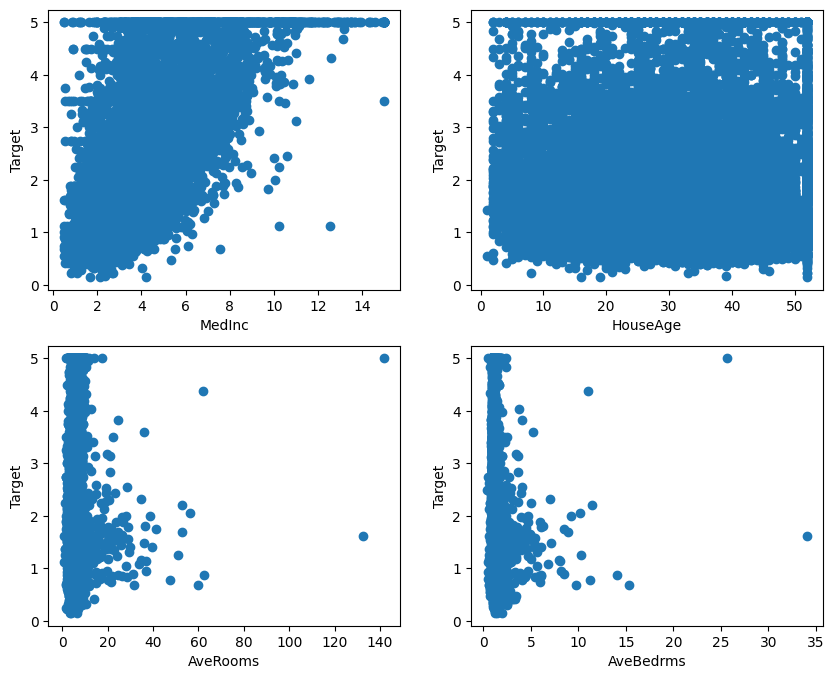

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


axes[0, 0].scatter(X_train[:, 0], y_train)
axes[0, 0].set_xlabel("MedInc")
axes[0, 0].set_ylabel("Target")

axes[0, 1].scatter(X_train[:, 1], y_train)
axes[0, 1].set_xlabel("HouseAge")
axes[0, 1].set_ylabel("Target")

axes[1, 0].scatter(X_train[:, 2], y_train)
axes[1, 0].set_xlabel("AveRooms")
axes[1, 0].set_ylabel("Target")

axes[1, 1].scatter(X_train[:, 3], y_train)
axes[1, 1].set_xlabel("AveBedrms")
axes[1, 1].set_ylabel("Target")

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow.keras.layers import Dense, Input 
from tensorflow.keras import Sequential 
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy 
from tensorflow.keras.activations import sigmoid

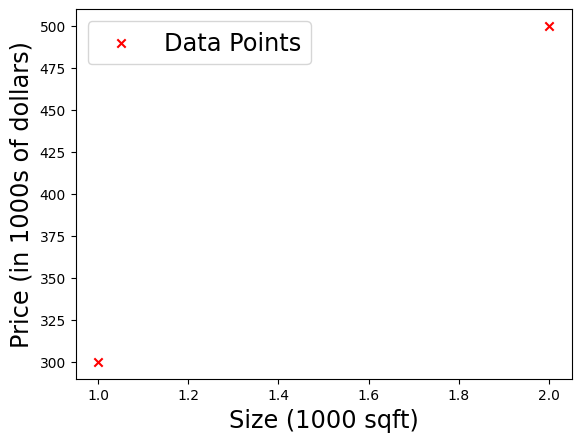

In [4]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)
Y_train = np.array([[300.0], [500.0]], dtype=np.float32)  

fig, ax = plt.subplots(1, 1)
ax.scatter(X_train, Y_train, marker = 'x', c ='r', label ='Data Points')
ax.legend( fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

In [12]:
linear_layer = tf.keras.layers.Dense(units=1, activation='linear')
a1 = linear_layer(X_train[0].reshape(1, 1)) 

In [13]:
set_w = np.array([[200]])
set_b = np.array([100])
linear_layer.set_weights([set_w, set_b]) 

In [14]:
a1 = linear_layer(X_train) 
alin =set_w @ X_train[0].reshape(1,1) +set_b

In [16]:
prediction_tf = linear_layer(X_train) 
prediction_np = X_train @ set_w + set_b

In [17]:
model = Sequential(
    [
        tf.keras.layers.Dense(1, input_dim=1, activation='sigmoid', name='L1') 
    ]
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
a1 = model.predict(X_train[0].reshape(1, 1))
print(a1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[0.15683301]]


In [49]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from sklearn.metrics import confusion_matrix, classification_report 

In [20]:
classes = 4 
m = 100 
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
std = 1.0 
X_train, y_train = make_blobs(n_samples=m, centers=centers, cluster_std=std, random_state=30)

In [21]:
print(np.unique(y_train)) 
print(y_train[:10]) 
print(X_train.shape)
print(y_train.shape) 

[0 1 2 3]
[3 3 3 0 3 3 3 3 2 0]
(100, 2)
(100,)


In [22]:
tf.random.set_seed(1234)
model = Sequential(
    [
        Dense(2, activation='relu', name='L1'), 
        Dense(4, activation='linear', name='L2')
    ]
)

In [23]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(0.01), 
)

model.fit(
    X_train, y_train, epochs=200
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1543  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0757
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0163
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9657
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9215
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8810
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8437
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8096
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7785
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7503 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7246
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7013
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6800
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6601
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6417
Epoch 16/200
4/4 ━━━━━━━━━━━━━━

In [24]:
l1 = model.get_layer("L1") 
W1, b1 = l1.get_weights()

In [27]:
l2 = model.get_layer("L2") 
W2, b2 = l2.get_weights() 

Xl2 = np.maximum(0, X_train @ W1 + b1) 

In [28]:
from ucimlrepo import fetch_ucirepo

handwritten_digits = fetch_ucirepo(id=80) 

X = handwritten_digits.data.features 
y = handwritten_digits.data.targets 

In [42]:
from sklearn.model_selection import train_test_split
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.models import Sequential

In [34]:
x_np = X.to_numpy() 
y_np = y.to_numpy() 
print(x_np.shape) 
print(y_np.shape) 

(5620, 64)
(5620, 1)


In [39]:
x_train, x_test, y_train, y_test = train_test_split(x_np, y_np, train_size=0.8)

In [45]:
handwritten_model = Sequential(
    [
        Dense(128, activation='relu', name = 'L1'), 
        Dense(10, activation='linear', name = 'L2') 
    ]
)

handwritten_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(0.01), 
)

handwritten_model.fit(x_train, y_train, epochs = 200) 

Epoch 1/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 379us/step - loss: 1.7751   
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - loss: 0.1657
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 0.1018
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 0.1401
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step - loss: 0.1065
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - loss: 0.0754
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.0841
Epoch 8/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step - loss: 0.0647
Epoch 9/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step - loss: 0.0830
Epoch 10/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 317us/step - loss: 0.1229  
Epoch 11/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - loss: 0.1072
Epoch 12/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - loss: 0.1310
Epoch 13/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - loss: 0.1335
Epoch 14/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step - loss: 0.0606
Epoch 15/2

In [46]:
y_predict = handwritten_model.predict(x_test) 

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step


In [47]:
y_predict_argmax = np.argmax(y_predict, axis=1) 

In [54]:
print(confusion_matrix(y_test, y_predict_argmax))
print(classification_report(y_test, y_predict_argmax))

[[113   0   0   0   2   0   0   0   0   0]
 [  0 103   0   0   0   0   0   0   3   0]
 [  0   0 114   0   0   1   0   0   0   0]
 [  0   0   0 110   0   0   0   0   0   0]
 [  0   0   0   0 108   0   0   0   0   0]
 [  2   0   0   0   0 111   0   0   1   1]
 [  0   0   0   0   1   0 113   0   0   0]
 [  0   0   1   0   0   0   0 116   0   0]
 [  0   2   0   0   0   0   0   0 110   0]
 [  0   2   0   0   1   2   0   0   1 106]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       115
           1       0.96      0.97      0.97       106
           2       0.99      0.99      0.99       115
           3       1.00      1.00      1.00       110
           4       0.96      1.00      0.98       108
           5       0.97      0.97      0.97       115
           6       1.00      0.99      1.00       114
           7       1.00      0.99      1.00       117
           8       0.96      0.98      0.97       112
           9       0.99     

(1124, 64)
1


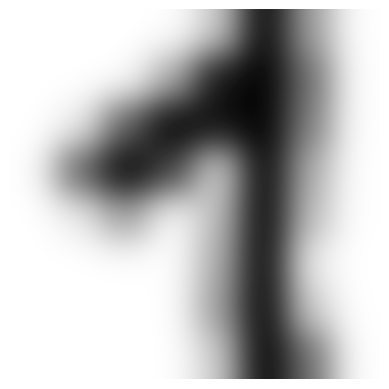

In [73]:
print(x_test.shape) 
print(y_predict_argmax[1])
side = 8 
plt.imshow(x_test[1].reshape(side, side), cmap='gray_r', interpolation='gaussian') 
plt.axis('off') 
plt.show()

## Advice for Applying Machine Learning

In [108]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.activations import relu, linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_blobs

In [93]:
x, y = make_blobs(n_samples=100, n_features=1, centers=None,
                  cluster_std=2.5, center_box=(-15, 15), random_state=3)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)
print(x_train.shape) 
print(y_train.shape) 

(70, 1)
(70,)


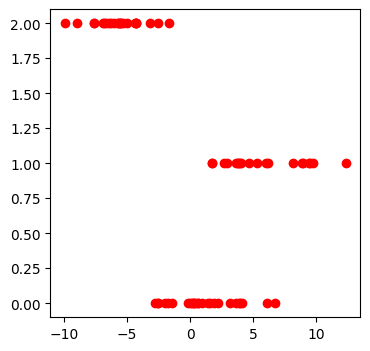

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4)) 
ax.scatter(x_train, y_train, color='r', label='train') 
# ax.scatter(x_test, y_test, color='b', label ='test') 
plt.show()

In [95]:
def eval_mse(y, yhat): 
    m = len(y)
    err = (1/(2*m)) * np.sum((y - yhat)**2) 
    return err

In [96]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

0.0050000000000000305

In [97]:
degree = 10 
linear_model = LinearRegression() 
poly = PolynomialFeatures(degree, include_bias = False) 
scaler = StandardScaler() 

In [99]:
x_train_poly_mapped = poly.fit_transform(x_train) 
x_train_scalled = scaler.fit_transform(x_train_poly_mapped) 
linear_model.fit(x_train_scalled, y_train) 

LinearRegression()

In [100]:
x_test_poly_mapped = poly.fit_transform(x_test) 
x_test_scaled = scaler.fit_transform(x_test_poly_mapped) 
yhat = linear_model.predict(x_test_scaled) 

In [102]:
mse = eval_mse(y_test, yhat) 
print(mse) 

6.1872349786963


In [110]:
class lin_model: 
    def __init__(self, degree, regularization = False, lambda_ = 1.0): 
        if not regularization: 
            self.linear_model = LinearRegression()
        else: 
            self.linear_model = Ridge(alpha=lambda_) 
        self.poly = PolynomialFeatures(degree, include_bias = False) 
        self.scaler = StandardScaler() 

    def fit(self, x_train, y_train): 
        x_train_mapped = self.poly.fit_transform(x_train) 
        x_train_scaled = self.scaler.fit_transform(x_train_mapped) 
        self.linear_model.fit(x_train_scaled, y_train) 

    def predict(self, x_test): 
        x_test_mapped = self.poly.fit_transform(x_test) 
        x_test_scaled = self.scaler.fit_transform(x_test_mapped) 
        y_hat = self.linear_model.predict(x_test_scaled) 
        return y_hat 

    def eval_mse(self, y, yhat): 
        m = len(y)
        err = (1/(2*m)) * np.sum((y - yhat)**2) 
        return err 

In [107]:
max_deg = 10 
mse_list = []

for i in range(1, max_deg + 1): 
    model = lin_model(i) 
    model.fit(x_train, y_train) 
    yhat = model.predict(x_test) 
    mse = model.eval_mse(y_test, yhat) 
    mse_list.append(mse)

smallest_deg = np.argmin(mse_list) + 1
print(smallest_deg, mse_list[smallest_deg - 1])

6 0.09979198024873179


In [114]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
n = len(lambda_range) 
lambda_mse_list = []
for i in range(n): 
    model = lin_model(6, regularization=True, lambda_ = lambda_range[i]) 
    model.fit(x_train, y_train) 
    yhat = model.predict(x_test) 
    mse = model.eval_mse(y_test, yhat) 
    lambda_mse_list.append(mse)

smallest_mse_lambda = np.argmin(lambda_mse_list) + 1
print(lambda_range[smallest_mse_lambda]) 

0.1


## Decision Tree

In [115]:
import numpy as np 
import matplotlib.pyplot as plt 

In [116]:
X_train = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],[0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_train = np.array([1,1,0,0,1,0,0,1,1,0])

In [118]:
def compute_entropy(y): 
    entropy = 0 

    if len(y) != 0: 
        p1 = len(y[y==1]) / len(y) 

        if p1 != 0 and p1 != 1: 
            entropy = -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1) 
        else: 
            entropy = 0 

    return entropy 

In [119]:
print("Entropy at root node: ", compute_entropy(y_train)) 

Entropy at root node:  1.0


In [121]:
def split_dataset(X, node_indices, feature): 
    left_indices = []
    right_indices = []
    for i in node_indices: 
        if X[i][feature] == 1: 
            left_indices.append(i) 
        else: 
            right_indices.append(i) 

    return left_indices, right_indices

In [124]:
root_indices = np.arange(len(X_train)) 
left, right = split_dataset(X_train, root_indices, 0) 
print(len(X_train[left]))

7


In [125]:
def compute_information_gain(X, y, node_indices, feature): 
    left_indices, right_indices = split_dataset(X, node_indices, feature) 
    X_left, y_left = X[left_indices], y[left_indices] 
    X_right, y_right = X[right_indices], y[right_indices] 
    X_node, y_node = X[node_indices], y[node_indices] 

    node_entropy = compute_entropy(y_node) 
    left_entropy = compute_entropy(y_left) 
    right_entropy = compute_entropy(y_right) 

    w_left = len(X_left) / len(X_node) 
    w_right = len(X_right) / len(X_node) 

    weighted_entropy = w_left * left_entropy - w_right * right_entropy 
    information_gain = node_entropy - weighted_entropy 
    return information_gain 

In [134]:
def get_best_feature(X, y, node_indices): 
    num_features = X.shape[1]
    best_feature = -1 

    max_info_gain = 0 
    for feature in range(num_features): 
        info_gain = compute_information_gain(X, y, node_indices, feature) 
        if info_gain > max_info_gain: 
            max_info_gain = info_gain 
            best_feature = feature

    return best_feature

In [135]:
best_feature = get_best_feature(X_train, y_train, root_indices) 
print(best_feature) 

1


In [144]:
tree = []

def build_recursive_tree(
    X, y, node_indices, max_depth, current_depth
):
    indentation = "  " * current_depth

    # Stop when maximum depth is reached
    if current_depth == max_depth:
        print(
            f"{indentation}Leaf node with indices: {node_indices}"
        )
        return

    best_feature = get_best_feature(X, y, node_indices)

    # Stop if no valid split can be found
    if best_feature == -1:
        print(
            f"{indentation}Leaf node with indices: {node_indices}"
        )
        return

    tree.append(
        (current_depth, best_feature, node_indices)
    )

    print(
        f"{indentation}Depth {current_depth}: "
        f"Split on feature {best_feature}"
    )

    left_indices, right_indices = split_dataset(
        X, node_indices, best_feature
    )

    build_recursive_tree(
        X,
        y,
        left_indices,
        max_depth,
        current_depth + 1
    )

    build_recursive_tree(
        X,
        y,
        right_indices,
        max_depth,
        current_depth + 1
    )

In [145]:
build_recursive_tree(X_train, y_train, root_indices, max_depth=2, current_depth=0) 

Depth 0: Split on feature 1
  Depth 1: Split on feature 0
    Leaf node with indices: [0, 4]
    Leaf node with indices: [5, 8]
  Depth 1: Split on feature 1
    Leaf node with indices: []
    Leaf node with indices: [1, 2, 3, 6, 7, 9]


## Optical Recognition of Handwritten Digits

In [212]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.activations import sigmoid, linear, relu
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [166]:
from ucimlrepo import fetch_ucirepo
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 

X = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets

X_np = X.to_numpy() 
y_np = y.to_numpy() 

In [167]:
x_train, x_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2)

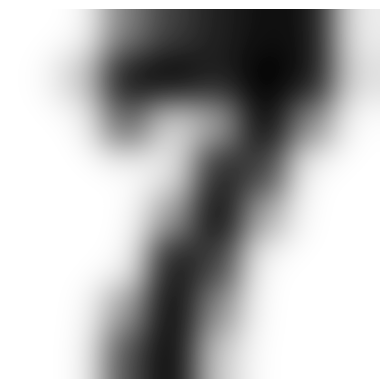

In [191]:
plt.imshow(x_train[10].reshape(8, 8), cmap='grey_r', interpolation='gaussian') 
plt.axis("off") 
plt.show()

In [204]:
handwritten_model = Sequential(
    [
        Dense(128, activation='relu', name = 'L1'),
        Dense(64, activation ='relu', name = 'L2'),
        Dense(32, activation='relu', name = 'L3') 
    ]
)

handwritten_model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=Adam(2e-5) 
)

handwritten_model.fit(x_train, y_train, epochs = 300) 

Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step - loss: 4.9061 
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - loss: 3.7460
Epoch 3/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 3.1142
Epoch 4/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 2.6644
Epoch 5/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 2.1981
Epoch 6/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 1.8700
Epoch 7/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 1.6815
Epoch 8/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 1.5271
Epoch 9/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 1.3346
Epoch 10/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - loss: 1.1589
Epoch 11/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 1.0450
Epoch 12/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 0.9632
Epoch 13/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 0.9001
Epoch 14/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - loss: 0.8491
Epoch 15/300
1

In [220]:
yhat = handwritten_model.predict(x_test) 
yhat = np.argmax(yhat, axis=1) 

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step


In [218]:
print(classification_report(yhat, y_test)) 
print(confusion_matrix(yhat, y_test)) 

              precision    recall  f1-score   support

           0       0.98      0.55      0.70       209
           1       1.00      0.93      0.96       121
           2       0.99      0.99      0.99       106
           3       1.00      0.97      0.98       125
           4       1.00      0.97      0.99       113
           5       0.97      0.99      0.98       112
           6       0.99      0.98      0.99       114
           7       1.00      1.00      1.00       104
           8       0.00      0.00      0.00         0
           9       0.98      0.93      0.95       120

    accuracy                           0.89      1124
   macro avg       0.89      0.83      0.85      1124
weighted avg       0.99      0.89      0.93      1124

[[114   0   1   0   0   0   0   0  94   0]
 [  0 112   0   0   0   0   1   0   8   0]
 [  0   0 105   0   0   0   0   0   1   0]
 [  0   0   0 121   0   1   0   0   2   1]
 [  2   0   0   0 110   0   0   0   1   0]
 [  0   0   0   0   0 111 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Decision Trees

In [235]:
from tensorflow.keras.utils import to_categorical

y_train_dt = to_categorical(y_train, num_classes = 10) 
y_test_dt = to_categorical(y_test, num_classes = 10) 

In [232]:
features = np.arange(len(np.unique(y)))
print(np.unique(y))

[1 2 3]
(4496, 1)


In [229]:
_, counts = np.unique(y_train, return_counts=True) 
probabilities = counts / len(y_train)

entropy = -np.sum(probabilities * np.log2(probabilities))

print(entropy) 

3.321708191324042


In [256]:
def compute_entropy(y):
    if len(y) == 0:                       # FIX: empty node -> 0 (avoids divide-by-zero)
        return 0
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities))


In [257]:
def split_dataset(X, node_indices, feature):
    left_indices, right_indices = [], []
    for i in node_indices:
        if X[i][feature] == 1:
            left_indices.append(i)
        else:
            right_indices.append(i)
    return left_indices, right_indices


In [258]:
def compute_information_gain(X, y, node_indices, feature):
    if len(node_indices) == 0:            # FIX: guard empty node
        return 0
    left_indices, right_indices = split_dataset(X, node_indices, feature)
    y_node, y_left, y_right = y[node_indices], y[left_indices], y[right_indices]

    w_left  = len(left_indices)  / len(node_indices)
    w_right = len(right_indices) / len(node_indices)
    weighted_entropy = w_left * compute_entropy(y_left) + w_right * compute_entropy(y_right)
    return compute_entropy(y_node) - weighted_entropy


In [259]:
def get_best_feature(X, y, node_indices):
    best_feature = -1
    max_info_gain = 0
    for feature in range(X.shape[1]):
        info_gain = compute_information_gain(X, y, node_indices, feature)
        if info_gain > max_info_gain:
            max_info_gain = info_gain      # FIX: was `info_gain = max_info_gain`
            best_feature  = feature
    return best_feature


In [250]:
tree = []
def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth):
    # stop at max depth or empty node
    if current_depth == max_depth or len(node_indices) == 0:
        print(" "*current_depth + "-"*current_depth, f"{branch_name} leaf node with indices", node_indices)
        return

    best_feature = get_best_feature(X, y, node_indices)   # FIX: was get_best_split (undefined)
    if best_feature == -1:                                # no informative split -> make a leaf
        print(" "*current_depth + "-"*current_depth, f"{branch_name} leaf node with indices", node_indices)
        return

    tree.append((current_depth, branch_name, best_feature, node_indices))
    print("-"*current_depth, f"Depth {current_depth}, {branch_name}: Split on feature {best_feature}")

    left_indices, right_indices = split_dataset(X, node_indices, best_feature)
    build_tree_recursive(X, y, left_indices,  "Left",  max_depth, current_depth+1)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth+1)


In [265]:
X_demo = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],
                   [0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_demo = np.array([1,1,0,0,1,0,0,1,1,0])

In [266]:
root_indices = np.arange(len(np.unique(y_train)))
build_tree_recursive(X_demo, y_demo, root_indices, "Root", max_depth=10, current_depth=0)

 Depth 0, Root: Split on feature 2
- Depth 1, Left: Split on feature 0
  -- Left leaf node with indices [0, 1, 4, 7]
  -- Right leaf node with indices [5]
- Depth 1, Right: Split on feature 1
  -- Left leaf node with indices [8]
  -- Right leaf node with indices [2, 3, 6, 9]


In [270]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, confusion_matrix 

digit_tree = DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=0)
digit_tree.fit(x_train, y_train.ravel()) 

y_pred = digit_tree.predict(x_test) 
print(classification_report(y_test, y_pred)) 
print(confusion_matrix(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       116
           1       0.89      0.96      0.92       112
           2       0.99      0.89      0.94       106
           3       0.91      0.94      0.93       121
           4       0.88      0.88      0.88       110
           5       0.93      0.91      0.92       114
           6       0.97      0.95      0.96       113
           7       0.89      0.89      0.89       104
           8       0.84      0.90      0.87       115
           9       0.84      0.82      0.83       113

    accuracy                           0.91      1124
   macro avg       0.91      0.91      0.91      1124
weighted avg       0.91      0.91      0.91      1124

[[109   0   0   0   2   1   0   1   2   1]
 [  0 107   0   1   0   1   1   0   1   1]
 [  0   0  94   1   1   0   1   1   7   1]
 [  0   1   0 114   0   0   0   0   2   4]
 [  0   1   0   0  97   0   0   5   1   6]
 [  1   2   0   0   1 104 